In [4]:
import pyarrow
import pandas as pd
import pathlib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

원본: 955338
work (pass&run): 675566
=== 1. Down x Yards-to-go (BINNED: 1-3,4-7,8-10,11+) [pass&run only] ===
ytg_binned    1-3    4-7    8-10    11+
down                                   
1            6010   8678  271910  11120
2           35043  70654   85993  33356
3           38996  45290   30663  25944
4            7203   2498    1162   1046

=== 2. Down x Yards-to-go (SEPARATE: 1..10,10+) [pass&run only] ===
ytg_sep      1      2      3      4      5      6      7      8      9      10    10+
down                                                                                 
1         2913   1532   1565   1674   3656   1636   1712   1724   1916  268270  11120
2        12624  10379  12040  14265  17527  18817  20045  19571  16403   50019  33356
3        16223  11540  11233  11492  11807  11220  10771   9670   8193   12800  25944
4         4619   1533   1051    844    734    539    381    283    218     661   1046


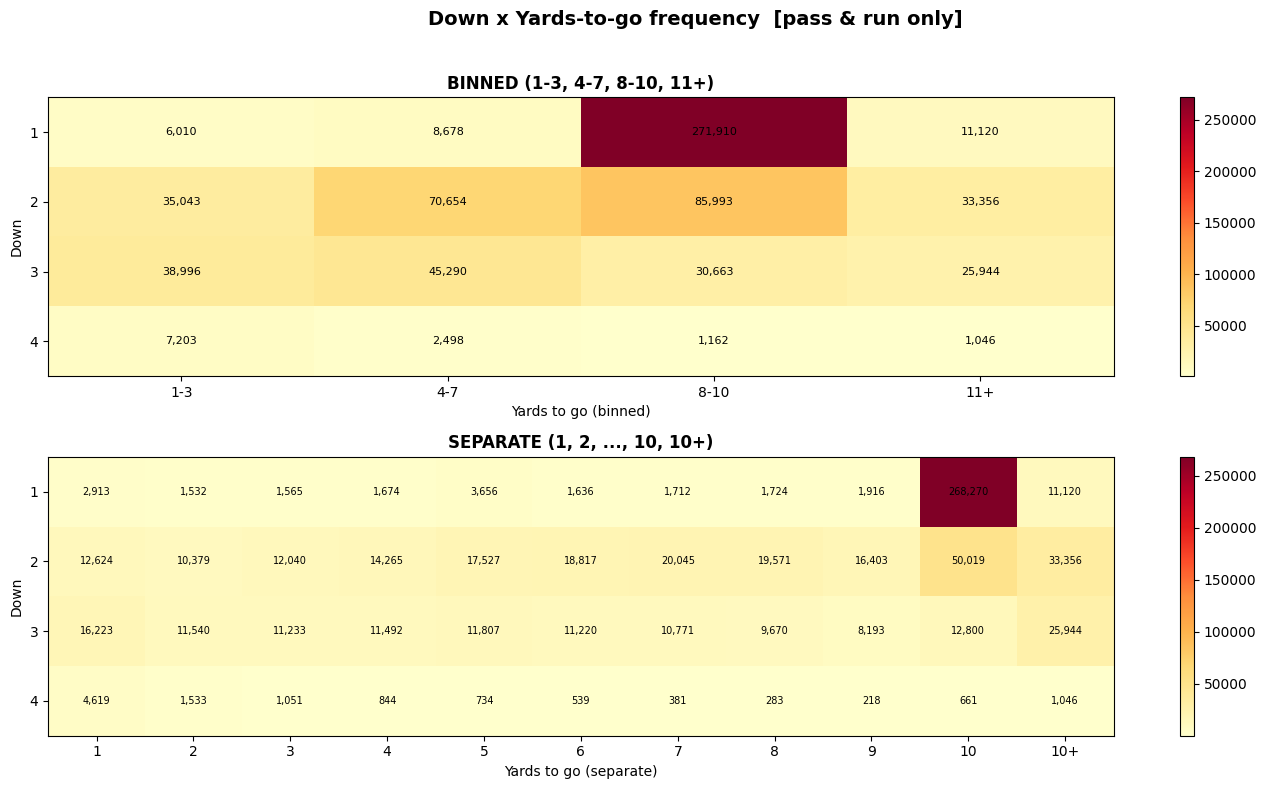


=== 3. State frequency (down4 x ytg4 x field15) [pass&run only] ===
  Theoretical max states : 240 = 240
  Observed states        : 224
  Min visits  : 1
  Median      : 1367
  Mean        : 3016
  Max visits  : 56452
  states <   5 visits : 10 (4.5%)
  states <  10 visits : 13 (5.8%)
  states <  30 visits : 14 (6.2%)
  states < 100 visits : 39 (17.4%)

  --- per-down breakdown ---
  down 1: 53 states, median 455 visits, 10 states <30 visits
  down 2: 57 states, median 3308 visits, 0 states <30 visits
  down 3: 57 states, median 1831 visits, 0 states <30 visits
  down 4: 57 states, median 116 visits, 4 states <30 visits

  --- state count grid (down x field, summed over ytg) ---
s_field  opp 1-5  opp 6-10  opp 11-15  opp 16-20  opp 21-25  opp 26-30  opp 31-35  opp 36-40  opp 41-45  opp 46-50  own 51-60  own 61-70  own 71-80  own 81-90  own 91-99
s_down                                                                                                                                       

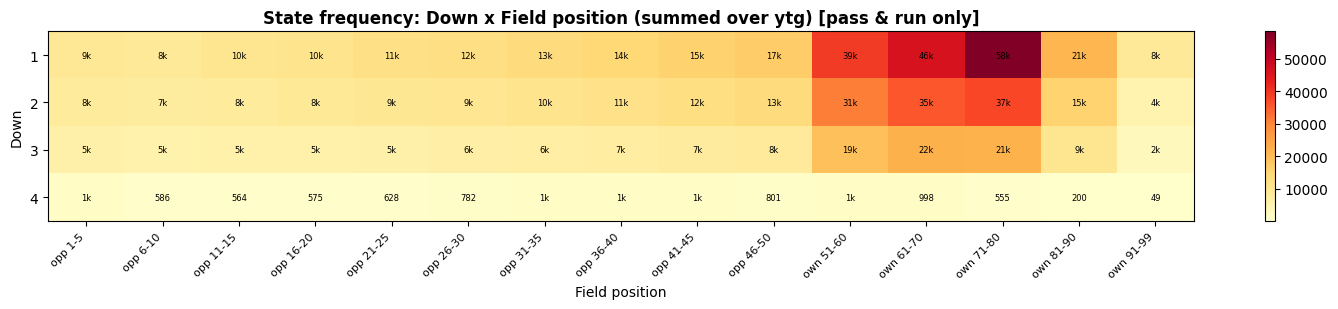



=== 4. NON pass/run event distributions ===
Total non-(pass/run) rows: 275,661

kickoff      n= 55,001  yardline median=35  mode=35
punt         n= 47,879  yardline median=66  mode=71
field_goal   n= 20,918  yardline median=20  mode=30
extra_point  n= 25,429  yardline median=15  mode=15
no_play      n= 88,333  yardline median=52  mode=75
qb_kneel     n=  8,202  yardline median=55  mode=80
qb_spike     n=  1,556  yardline median=33  mode=25


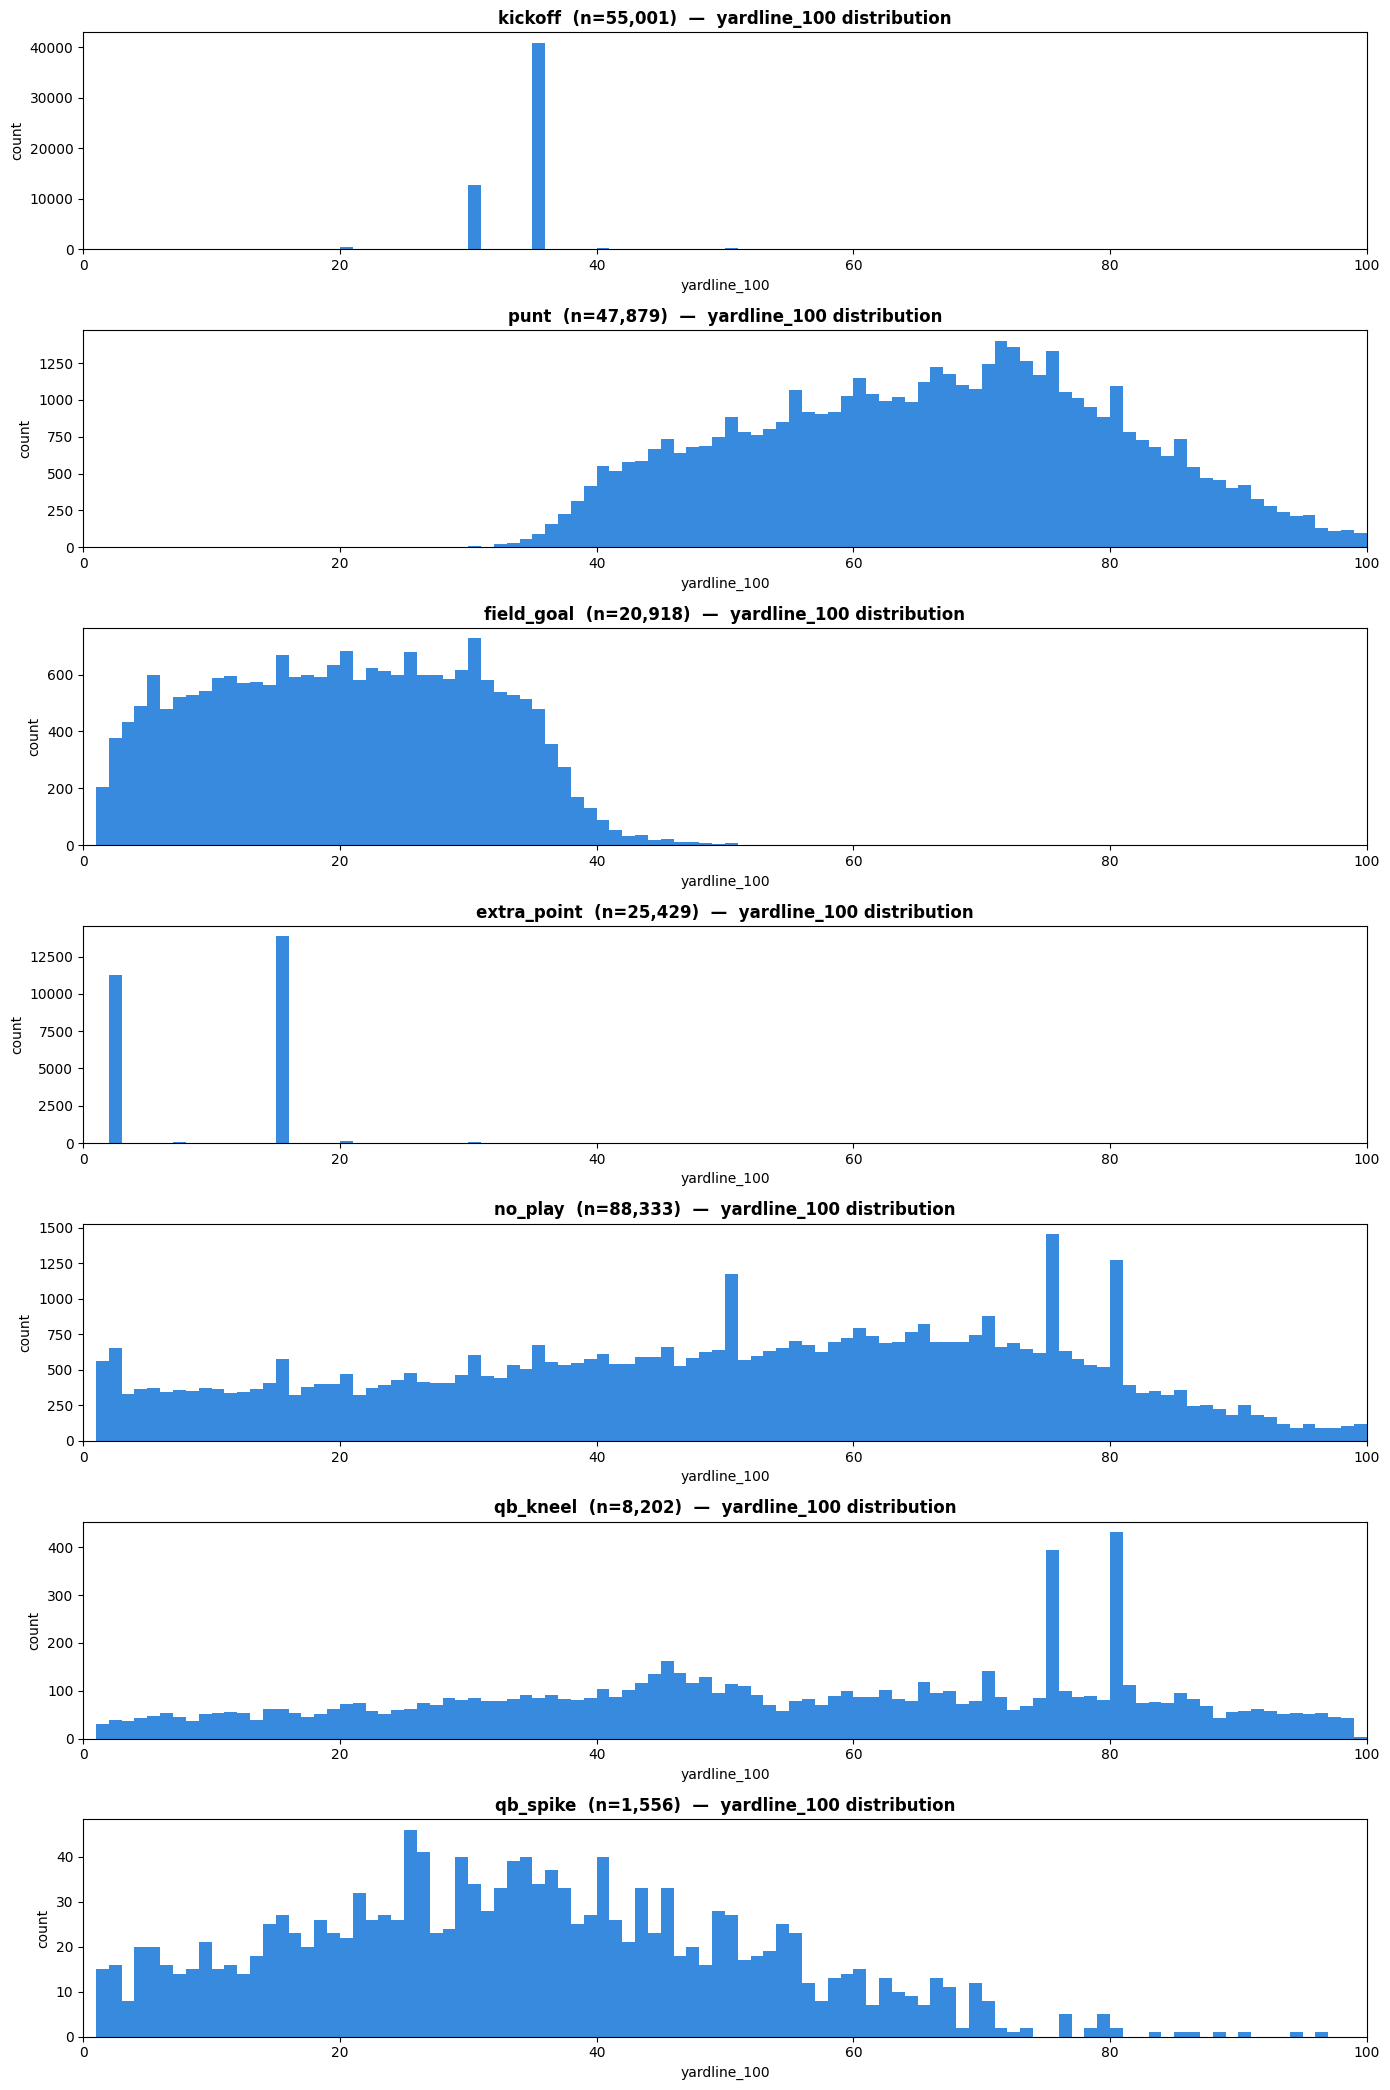


=== non-offensive event summary table ===
  play_type  count has_down_% yl_median yl_mode
    kickoff  55001         0%        35      35
       punt  47879       100%        66      71
 field_goal  20918       100%        20      30
extra_point  25429         0%        15      15
    no_play  88333        55%        52      75
   qb_kneel   8202       100%        55      80
   qb_spike   1556       100%        33      25


In [11]:
dfs = []
for year in range(2006, 2026):
    file_path = Path("data") / "pbp" / f"play_by_play_{year}.parquet"
    dfs.append(pd.read_parquet(file_path))
OFFENSIVE_PLAYS = ['pass', 'run']

work = df[df['play_type'].isin(OFFENSIVE_PLAYS)].copy()

if 'special_teams_play' in work.columns:
    work = work[work['special_teams_play'] != 1]
if 'aborted_play' in work.columns:
    work = work[work['aborted_play'] != 1]

work = work.dropna(subset=['down', 'ydstogo', 'yardline_100', 'posteam',
                           'fixed_drive', 'fixed_drive_result'])

print("원본:", len(df))
print("work (pass&run):", len(work))
df = pd.concat(dfs, ignore_index=True)
def bin_down_new(d):
    return int(d)

def bin_ytg_binned(y):
    y = int(y)
    if y <= 3:   return '1-3'
    if y <= 7:   return '4-7'
    if y <= 10:  return '8-10'
    return '11+'

def bin_ytg_separate(y):
    y = int(y)
    return '10+' if y > 10 else str(y)

FIELD_BINS = [
    ('opp 1-5', 1, 5), ('opp 6-10', 6, 10), ('opp 11-15', 11, 15),
    ('opp 16-20', 16, 20), ('opp 21-25', 21, 25), ('opp 26-30', 26, 30),
    ('opp 31-35', 31, 35), ('opp 36-40', 36, 40), ('opp 41-45', 41, 45),
    ('opp 46-50', 46, 50),
    ('own 51-60', 51, 60), ('own 61-70', 61, 70), ('own 71-80', 71, 80),
    ('own 81-90', 81, 90), ('own 91-99', 91, 99),
]
_field_lookup = {v: label for label, lo, hi in FIELD_BINS for v in range(lo, hi + 1)}
def bin_field_new(y):
    return _field_lookup[int(y)]

FIELD_ORDER = [b[0] for b in FIELD_BINS]

w = work.dropna(subset=['down', 'ydstogo', 'yardline_100']).copy()
w['down'] = w['down'].astype(int)

w['ytg_binned'] = w['ydstogo'].map(bin_ytg_binned)
ytg_binned_order = ['1-3', '4-7', '8-10', '11+']
freq_binned = (w.groupby(['down', 'ytg_binned']).size()
                 .unstack(fill_value=0)
                 .reindex(columns=ytg_binned_order, fill_value=0))
print("=== 1. Down x Yards-to-go (BINNED: 1-3,4-7,8-10,11+) [pass&run only] ===")
print(freq_binned.to_string())

w['ytg_sep'] = w['ydstogo'].map(bin_ytg_separate)
ytg_sep_order = [str(i) for i in range(1, 11)] + ['10+']
freq_sep = (w.groupby(['down', 'ytg_sep']).size()
              .unstack(fill_value=0)
              .reindex(columns=ytg_sep_order, fill_value=0))
print("\n=== 2. Down x Yards-to-go (SEPARATE: 1..10,10+) [pass&run only] ===")
print(freq_sep.to_string())

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Down x Yards-to-go frequency  [pass & run only]',
             fontsize=14, fontweight='bold')

im0 = axes[0].imshow(freq_binned.values, aspect='auto', cmap='YlOrRd')
axes[0].set_xticks(range(len(ytg_binned_order)))
axes[0].set_xticklabels(ytg_binned_order)
axes[0].set_yticks(range(4)); axes[0].set_yticklabels([1, 2, 3, 4])
axes[0].set_xlabel('Yards to go (binned)'); axes[0].set_ylabel('Down')
axes[0].set_title('BINNED (1-3, 4-7, 8-10, 11+)', fontweight='bold')
for i in range(4):
    for j in range(len(ytg_binned_order)):
        axes[0].text(j, i, f'{freq_binned.values[i,j]:,}',
                     ha='center', va='center', fontsize=8)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(freq_sep.values, aspect='auto', cmap='YlOrRd')
axes[1].set_xticks(range(len(ytg_sep_order)))
axes[1].set_xticklabels(ytg_sep_order)
axes[1].set_yticks(range(4)); axes[1].set_yticklabels([1, 2, 3, 4])
axes[1].set_xlabel('Yards to go (separate)'); axes[1].set_ylabel('Down')
axes[1].set_title('SEPARATE (1, 2, ..., 10, 10+)', fontweight='bold')
for i in range(4):
    for j in range(len(ytg_sep_order)):
        axes[1].text(j, i, f'{freq_sep.values[i,j]:,}',
                     ha='center', va='center', fontsize=7)
plt.colorbar(im1, ax=axes[1])
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('freq_down_ytg_passrun.png', dpi=130, bbox_inches='tight')
plt.show()

w['s_down']  = w['down'].map(bin_down_new)
w['s_ytg']   = w['ydstogo'].map(bin_ytg_binned)
w['s_field'] = w['yardline_100'].map(bin_field_new)
w['state']   = list(zip(w['s_down'], w['s_ytg'], w['s_field']))

state_freq = w['state'].value_counts()
print("\n=== 3. State frequency (down4 x ytg4 x field15) [pass&run only] ===")
print(f"  Theoretical max states : {4*4*15} = 240")
print(f"  Observed states        : {state_freq.size}")
print(f"  Min visits  : {state_freq.min()}")
print(f"  Median      : {int(state_freq.median())}")
print(f"  Mean        : {state_freq.mean():.0f}")
print(f"  Max visits  : {state_freq.max()}")
for t in [5, 10, 30, 100]:
    c = (state_freq < t).sum()
    print(f"  states < {t:>3} visits : {c} ({100*c/state_freq.size:.1f}%)")

print("\n  --- per-down breakdown ---")
for d in [1, 2, 3, 4]:
    sub = w[w['s_down'] == d]['state'].value_counts()
    print(f"  down {d}: {sub.size} states, "
          f"median {int(sub.median())} visits, "
          f"{(sub<30).sum()} states <30 visits")

print("\n  --- state count grid (down x field, summed over ytg) ---")
grid = (w.groupby(['s_down', 's_field']).size()
          .unstack(fill_value=0)
          .reindex(columns=FIELD_ORDER, fill_value=0))
print(grid.to_string())

fig, ax = plt.subplots(figsize=(15, 3.2))
im = ax.imshow(grid.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(FIELD_ORDER)))
ax.set_xticklabels(FIELD_ORDER, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(4)); ax.set_yticklabels([1, 2, 3, 4])
ax.set_xlabel('Field position'); ax.set_ylabel('Down')
ax.set_title('State frequency: Down x Field position (summed over ytg) [pass & run only]',
             fontweight='bold')
for i in range(4):
    for j in range(len(FIELD_ORDER)):
        ax.text(j, i, f'{grid.values[i,j]//1000}k' if grid.values[i,j] >= 1000
                else f'{grid.values[i,j]}',
                ha='center', va='center', fontsize=6)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('freq_state_grid_passrun.png', dpi=130, bbox_inches='tight')
plt.show()

non_off = df[~df['play_type'].isin(['pass', 'run'])].copy()

print("\n\n=== 4. NON pass/run event distributions ===")
print(f"Total non-(pass/run) rows: {len(non_off):,}\n")

event_types = ['kickoff', 'punt', 'field_goal', 'extra_point',
               'no_play', 'qb_kneel', 'qb_spike']

fig, axes = plt.subplots(len(event_types), 1, figsize=(14, 3*len(event_types)))
for ax, et in zip(axes, event_types):
    sub = non_off[non_off['play_type'] == et]
    if len(sub) == 0 or sub['yardline_100'].notna().sum() == 0:
        ax.set_title(f'{et}: no yardline data (n={len(sub):,})')
        ax.axis('off')
        continue
    yl = sub['yardline_100'].dropna().astype(int)
    ax.hist(yl, bins=range(0, 101, 1), color='#378ADD', edgecolor='none')
    ax.set_title(f'{et}  (n={len(sub):,})  —  yardline_100 distribution',
                 fontweight='bold')
    ax.set_xlabel('yardline_100'); ax.set_ylabel('count')
    ax.set_xlim(0, 100)
    print(f"{et:<12} n={len(sub):>7,}  "
          f"yardline median={yl.median():.0f}  "
          f"mode={yl.mode().iloc[0] if len(yl.mode()) else 'NA'}")
plt.tight_layout()
plt.savefig('nonoffensive_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

print("\n=== non-offensive event summary table ===")
summary = []
for et in event_types:
    sub = non_off[non_off['play_type'] == et]
    summary.append({
        'play_type': et,
        'count': len(sub),
        'has_down_%': f"{100*sub['down'].notna().mean():.0f}%",
        'yl_median': f"{sub['yardline_100'].median():.0f}" if sub['yardline_100'].notna().any() else 'NA',
        'yl_mode': f"{sub['yardline_100'].mode().iloc[0]:.0f}" if sub['yardline_100'].notna().any() and len(sub['yardline_100'].mode()) else 'NA',
    })
print(pd.DataFrame(summary).to_string(index=False))

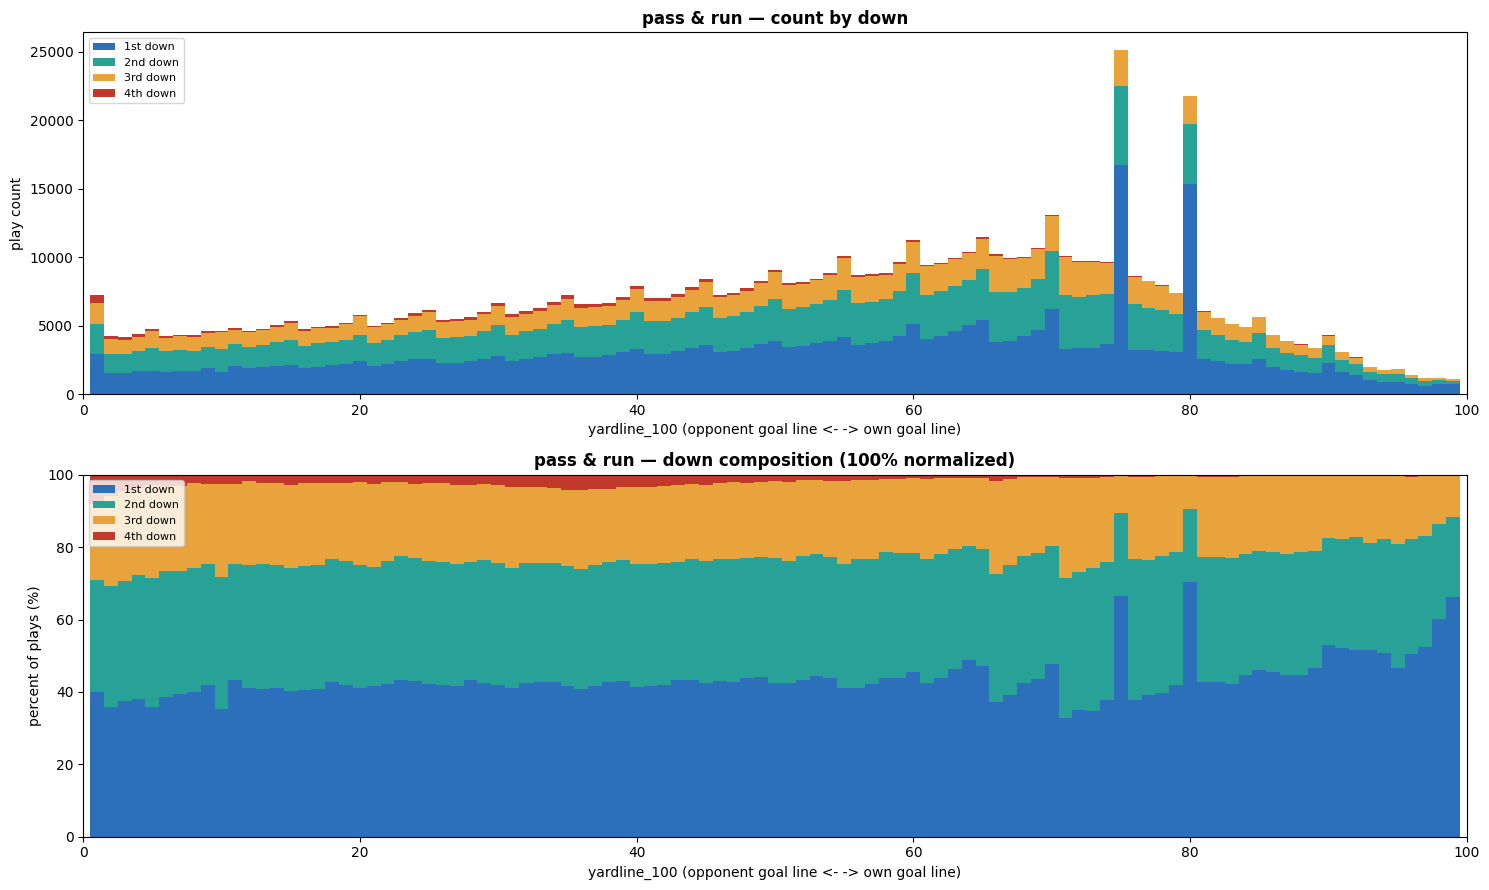

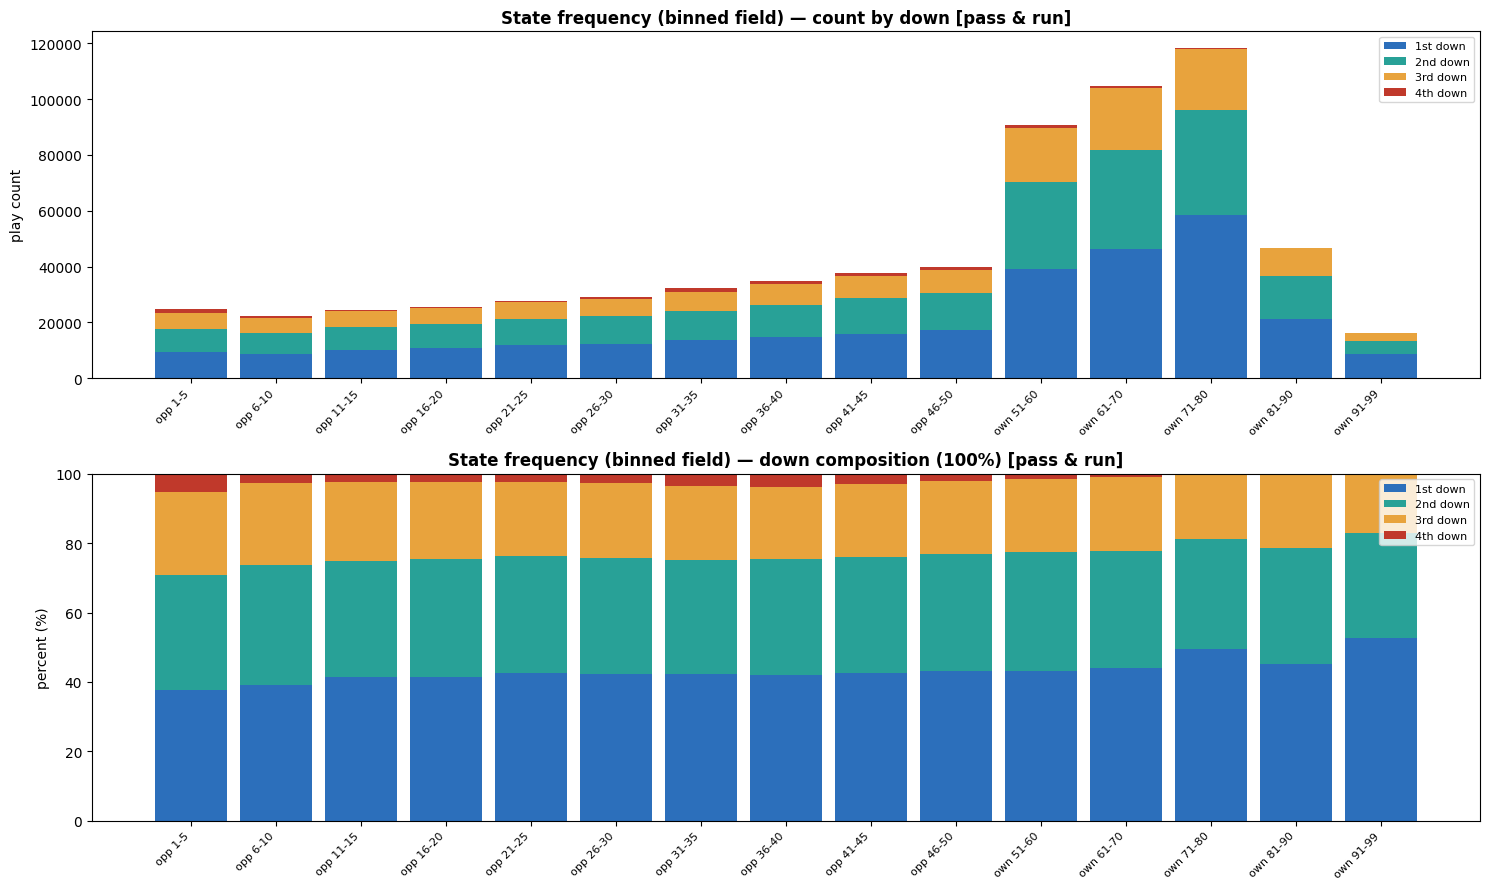

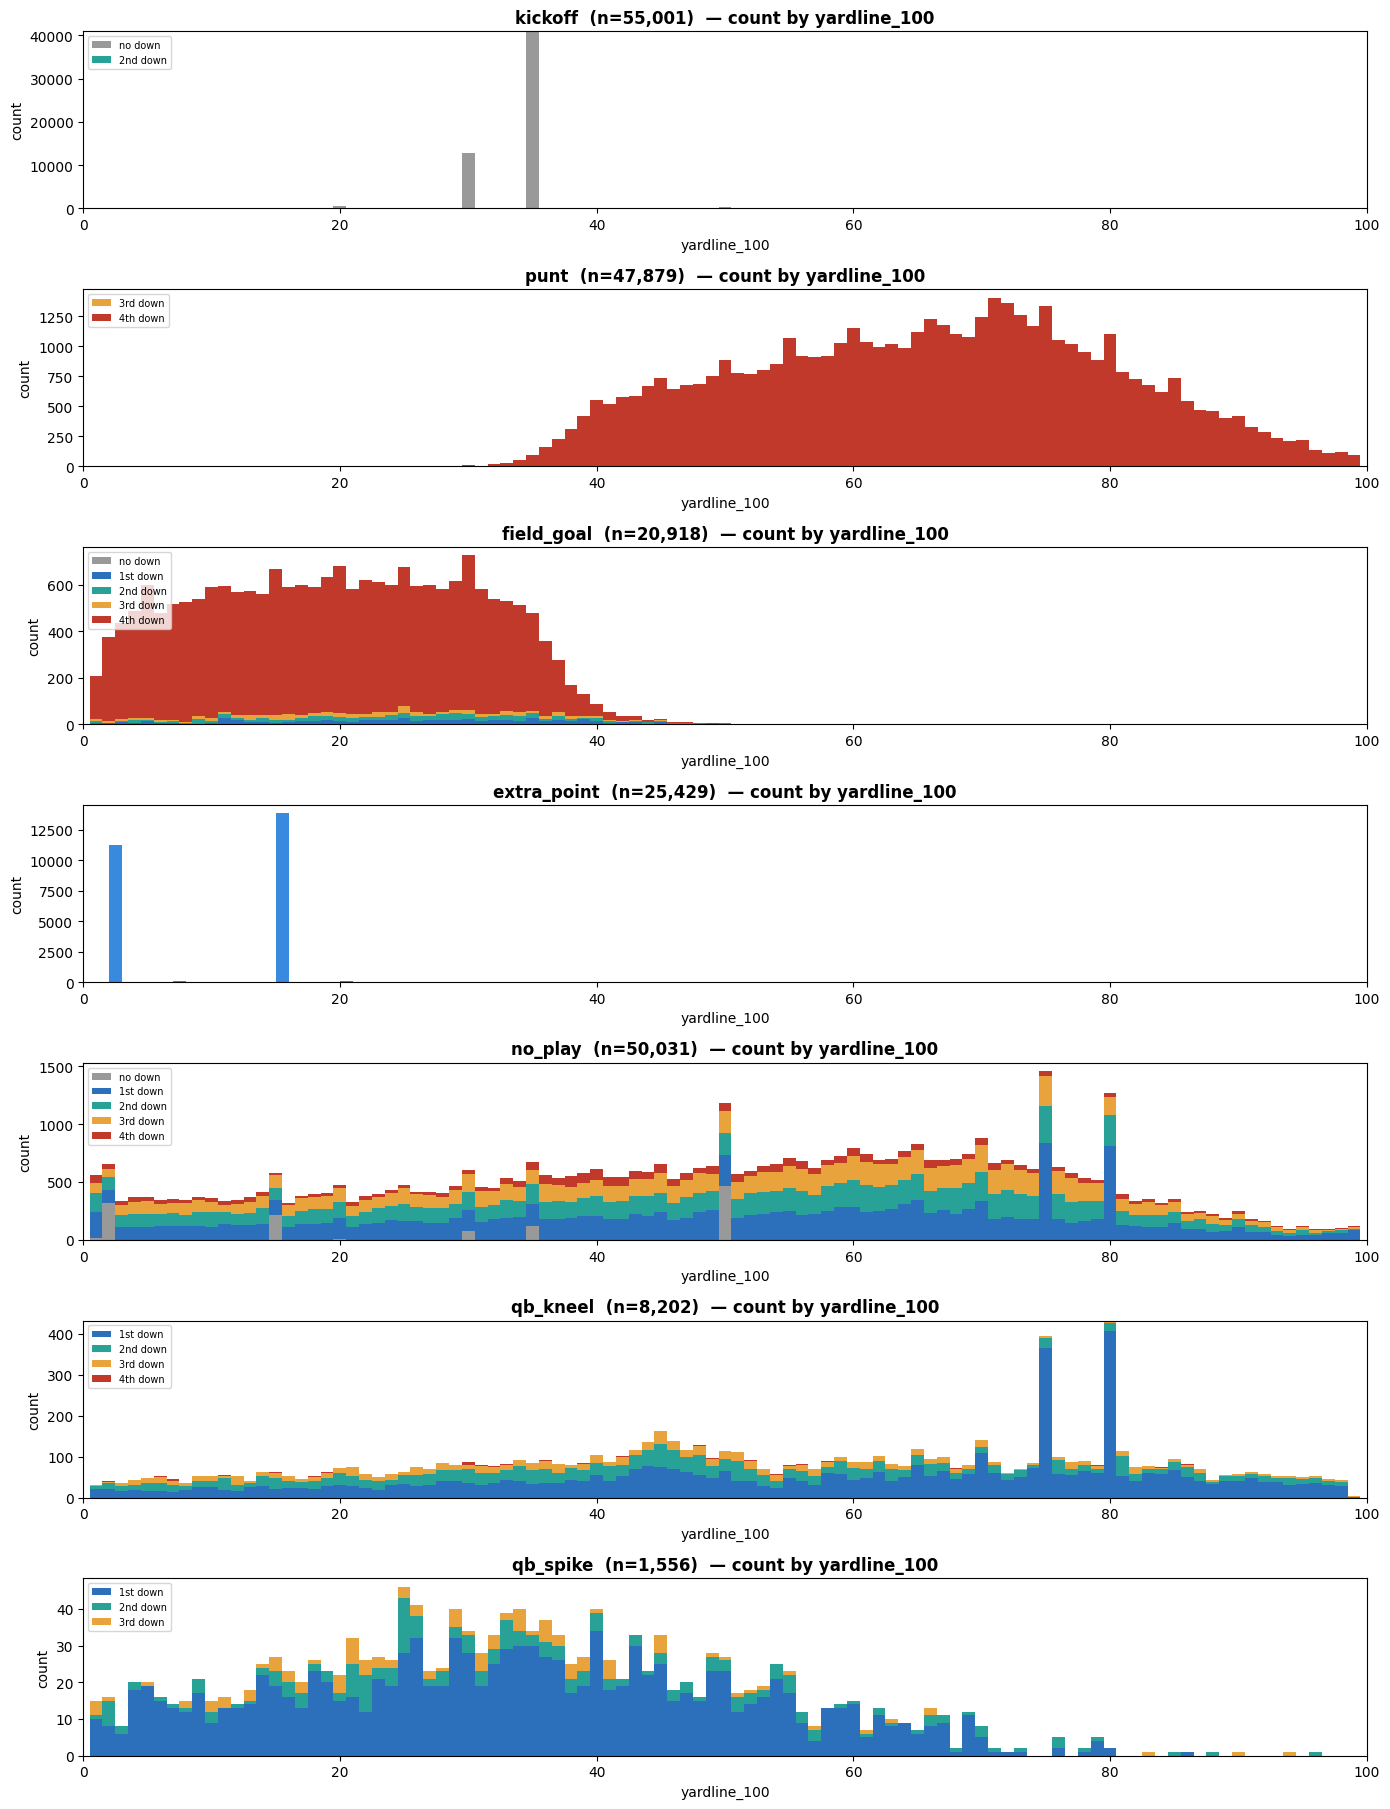

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DOWN_COLORS = {1: '#2C6FBB', 2: '#28A197', 3: '#E8A33D', 4: '#C0392B'}
DOWN_LABELS = {1: '1st down', 2: '2nd down', 3: '3rd down', 4: '4th down'}

def stacked_by_down(sub, title, ax_count, ax_pct):
    s = sub.dropna(subset=['down', 'yardline_100']).copy()
    s['down'] = s['down'].astype(int)
    s['yl'] = s['yardline_100'].astype(int)
    s = s[(s['yl'] >= 1) & (s['yl'] <= 99)]

    pivot = (s.groupby(['yl', 'down']).size()
               .unstack(fill_value=0)
               .reindex(index=range(1, 100), fill_value=0)
               .reindex(columns=[1, 2, 3, 4], fill_value=0))
    x = pivot.index.values

    bottom = np.zeros(len(x))
    for d in [1, 2, 3, 4]:
        ax_count.bar(x, pivot[d].values, bottom=bottom, width=1.0,
                     color=DOWN_COLORS[d], label=DOWN_LABELS[d])
        bottom += pivot[d].values
    ax_count.set_xlim(0, 100)
    ax_count.set_xlabel('yardline_100 (opponent goal line <- -> own goal line)')
    ax_count.set_ylabel('play count')
    ax_count.set_title(f'{title} — count by down', fontweight='bold')
    ax_count.legend(loc='upper left', fontsize=8)

    row_tot = pivot.sum(axis=1).replace(0, np.nan)
    pct = pivot.div(row_tot, axis=0).fillna(0) * 100
    bottom = np.zeros(len(x))
    for d in [1, 2, 3, 4]:
        ax_pct.bar(x, pct[d].values, bottom=bottom, width=1.0,
                   color=DOWN_COLORS[d], label=DOWN_LABELS[d])
        bottom += pct[d].values
    ax_pct.set_xlim(0, 100); ax_pct.set_ylim(0, 100)
    ax_pct.set_xlabel('yardline_100 (opponent goal line <- -> own goal line)')
    ax_pct.set_ylabel('percent of plays (%)')
    ax_pct.set_title(f'{title} — down composition (100% normalized)',
                     fontweight='bold')
    ax_pct.legend(loc='upper left', fontsize=8)

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
stacked_by_down(work, 'pass & run', axes[0], axes[1])
plt.tight_layout()
plt.savefig('down_stacked_passrun.png', dpi=130, bbox_inches='tight')
plt.show()

s = work.dropna(subset=['down', 'ydstogo', 'yardline_100']).copy()
s['down'] = s['down'].astype(int)
s['s_down']  = s['down'].map(bin_down_new)
s['s_ytg']   = s['ydstogo'].map(bin_ytg_binned)
s['s_field'] = s['yardline_100'].map(bin_field_new)
s['state']   = list(zip(s['s_down'], s['s_ytg'], s['s_field']))

grid = (s.groupby(['s_field', 's_down']).size()
          .unstack(fill_value=0)
          .reindex(index=FIELD_ORDER, fill_value=0)
          .reindex(columns=[1, 2, 3, 4], fill_value=0))
x = np.arange(len(FIELD_ORDER))

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

bottom = np.zeros(len(FIELD_ORDER))
for d in [1, 2, 3, 4]:
    axes[0].bar(x, grid[d].values, bottom=bottom, width=0.85,
                color=DOWN_COLORS[d], label=DOWN_LABELS[d])
    bottom += grid[d].values
axes[0].set_xticks(x); axes[0].set_xticklabels(FIELD_ORDER, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('play count')
axes[0].set_title('State frequency (binned field) — count by down [pass & run]',
                  fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8)

row_tot = grid.sum(axis=1).replace(0, np.nan)
pct = grid.div(row_tot, axis=0).fillna(0) * 100
bottom = np.zeros(len(FIELD_ORDER))
for d in [1, 2, 3, 4]:
    axes[1].bar(x, pct[d].values, bottom=bottom, width=0.85,
                color=DOWN_COLORS[d], label=DOWN_LABELS[d])
    bottom += pct[d].values
axes[1].set_xticks(x); axes[1].set_xticklabels(FIELD_ORDER, rotation=45, ha='right', fontsize=8)
axes[1].set_ylim(0, 100); axes[1].set_ylabel('percent (%)')
axes[1].set_title('State frequency (binned field) — down composition (100%) [pass & run]',
                  fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('down_stacked_binned_passrun.png', dpi=130, bbox_inches='tight')
plt.show()

non_off = df[~df['play_type'].isin(['pass', 'run'])].copy()
event_types = ['kickoff', 'punt', 'field_goal', 'extra_point',
               'no_play', 'qb_kneel', 'qb_spike']

n_ev = len(event_types)
fig, axes = plt.subplots(n_ev, 1, figsize=(14, 2.6 * n_ev))
for ax, et in zip(axes, event_types):
    sub = non_off[non_off['play_type'] == et].dropna(subset=['yardline_100']).copy()
    if len(sub) == 0:
        ax.set_title(f'{et}: no data'); ax.axis('off'); continue
    has_down = sub['down'].notna().any()
    sub['yl'] = sub['yardline_100'].astype(int)
    sub = sub[(sub['yl'] >= 1) & (sub['yl'] <= 99)]
    if has_down:
        sub['down'] = sub['down'].fillna(0).astype(int)
        pivot = (sub.groupby(['yl', 'down']).size()
                   .unstack(fill_value=0)
                   .reindex(index=range(1, 100), fill_value=0))
        xx = pivot.index.values
        bottom = np.zeros(len(xx))
        for d in sorted(pivot.columns):
            col = DOWN_COLORS.get(d, '#999999')
            lab = DOWN_LABELS.get(d, f'down {d}' if d else 'no down')
            ax.bar(xx, pivot[d].values, bottom=bottom, width=1.0, color=col, label=lab)
            bottom += pivot[d].values
        ax.legend(loc='upper left', fontsize=7)
    else:
        yl = sub['yl']
        ax.hist(yl, bins=range(0, 101, 1), color='#378ADD')
    ax.set_xlim(0, 100)
    ax.set_title(f'{et}  (n={len(sub):,})  — count by yardline_100', fontweight='bold')
    ax.set_xlabel('yardline_100'); ax.set_ylabel('count')
plt.tight_layout()
plt.savefig('nonoffensive_by_down.png', dpi=130, bbox_inches='tight')
plt.show()

In [55]:
df[['play_id', 'game_id', 'season_type', 'week', 'posteam', 'posteam_type', 'defteam',
    'yardline_100', 'game_date', 'drive', 'qtr', 'down', 'ydstogo', 
    'yards_gained', 'field_goal_result', 'td_team', 'punt_attempt', 'quarter_end',
    'fumble_lost', 'interception', 'safety', 'fourth_down_failed',
    'posteam_score', 'defteam_score', 'score_differential', 
    'ep', 'wp', 'vegas_wp', 'spread_line', 'total_line', 'surface', 'temp', 'wind',
    'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining'
]].head(50)

,play_id,game_id,season_type,week,posteam,posteam_type,defteam,yardline_100,game_date,drive,...,wp,vegas_wp,spread_line,total_line,surface,temp,wind,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining
0,1.0,2006_01_ATL_CAR,REG,1,None,None,None,NaN,2006-09-10,NaN,...,0.422024,0.310562,4.5,39.0,grass,86.0,5.0,900.0,1800.0,3600.0
1,36.0,2006_01_ATL_CAR,REG,1,ATL,away,CAR,30.0,2006-09-10,1.0,...,0.422024,0.310562,4.5,39.0,grass,86.0,5.0,900.0,1800.0,3600.0
2,58.0,2006_01_ATL_CAR,REG,1,ATL,away,CAR,67.0,2006-09-10,1.0,...,0.439629,0.329839,4.5,39.0,grass,86.0,5.0,894.0,1794.0,3594.0
3,80.0,2006_01_ATL_CAR,REG,1,ATL,away,CAR,62.0,2006-09-10,1.0,...,0.441971,0.344370,4.5,39.0,grass,86.0,5.0,858.0,1758.0,3558.0
4,102.0,2006_01_ATL_CAR,REG,1,ATL,away,CAR,63.0,2006-09-10,1.0,...,0.418461,0.339631,4.5,39.0,grass,86.0,5.0,813.0,1713.0,3513.0
5,126.0,2006_01_ATL_CAR,REG,1,ATL,away,CAR,53.0,2006-09-10,1.0,...,0.462427,0.372068,4.5,39.0,grass,86.0,5.0,778.0,1678.0,3478.0
6,159.0,2006_01_ATL_CAR,REG,1,ATL,away,CAR,38.0,2006-09-10,1.0,...,0.530412,0.413574,4.5,39.0,grass,86.0,5.0,771.0,1671.0,3471.0
7,183.0,2006_01_ATL_CAR,REG,1,ATL,away,CAR,33.0,2006-09-10,1.0,...,0.517820,0.397170,4.5,39.0,grass,86.0,5.0,737.0,1637.0,3437.0
8,205.0,2006_01_ATL_CAR,REG,1,ATL,away,CAR,27.0,2006-09-10,1.0,...,0.545878,0.439104,4.5,39.0,grass,86.0,5.0,713.0,1613.0,3413.0
9,227.0,2006_01_ATL_CAR,REG,1,ATL,away,CAR,27.0,2006-09-10,1.0,...,0.530411,0.420032,4.5,39.0,grass,86.0,5.0,708.0,1608.0,3408.0


In [72]:
import sys
!{sys.executable} -m pip install scikit-learn xgboost
import sklearn
import xgboost
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

  Using cached xgboost-3.4.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.0-py3-none-win_amd64.whl (48.9 MB)
sklearn: 1.9.0
xgboost: 3.4.0


EVAL 1: SEASON SPLIT (train 2006-2021, test per season 2022-2025)

--- target: yards_gained ---
                MAE            RMSE        
model        Linear XGBoost  Linear XGBoost
test_season                                
2022         5.6741  5.6694  8.4524  8.4425
2023         5.7033  5.7052  8.5305  8.5225
2024         5.6750  5.6718  8.5304  8.5185
2025         5.6099  5.6053  8.3658  8.3532

--- target: ep ---
                MAE            RMSE        
model        Linear XGBoost  Linear XGBoost
test_season                                
2022         0.2960  0.2747  0.3957  0.3701
2023         0.2928  0.2722  0.3889  0.3629
2024         0.2959  0.2767  0.3944  0.3728
2025         0.2922  0.2724  0.3912  0.3688

--- target: wp ---
                MAE            RMSE        
model        Linear XGBoost  Linear XGBoost
test_season                                
2022         0.2285  0.2265  0.2774  0.2757
2023         0.2376  0.2349  0.2862  0.2838
2024         0.2383  0.2366 

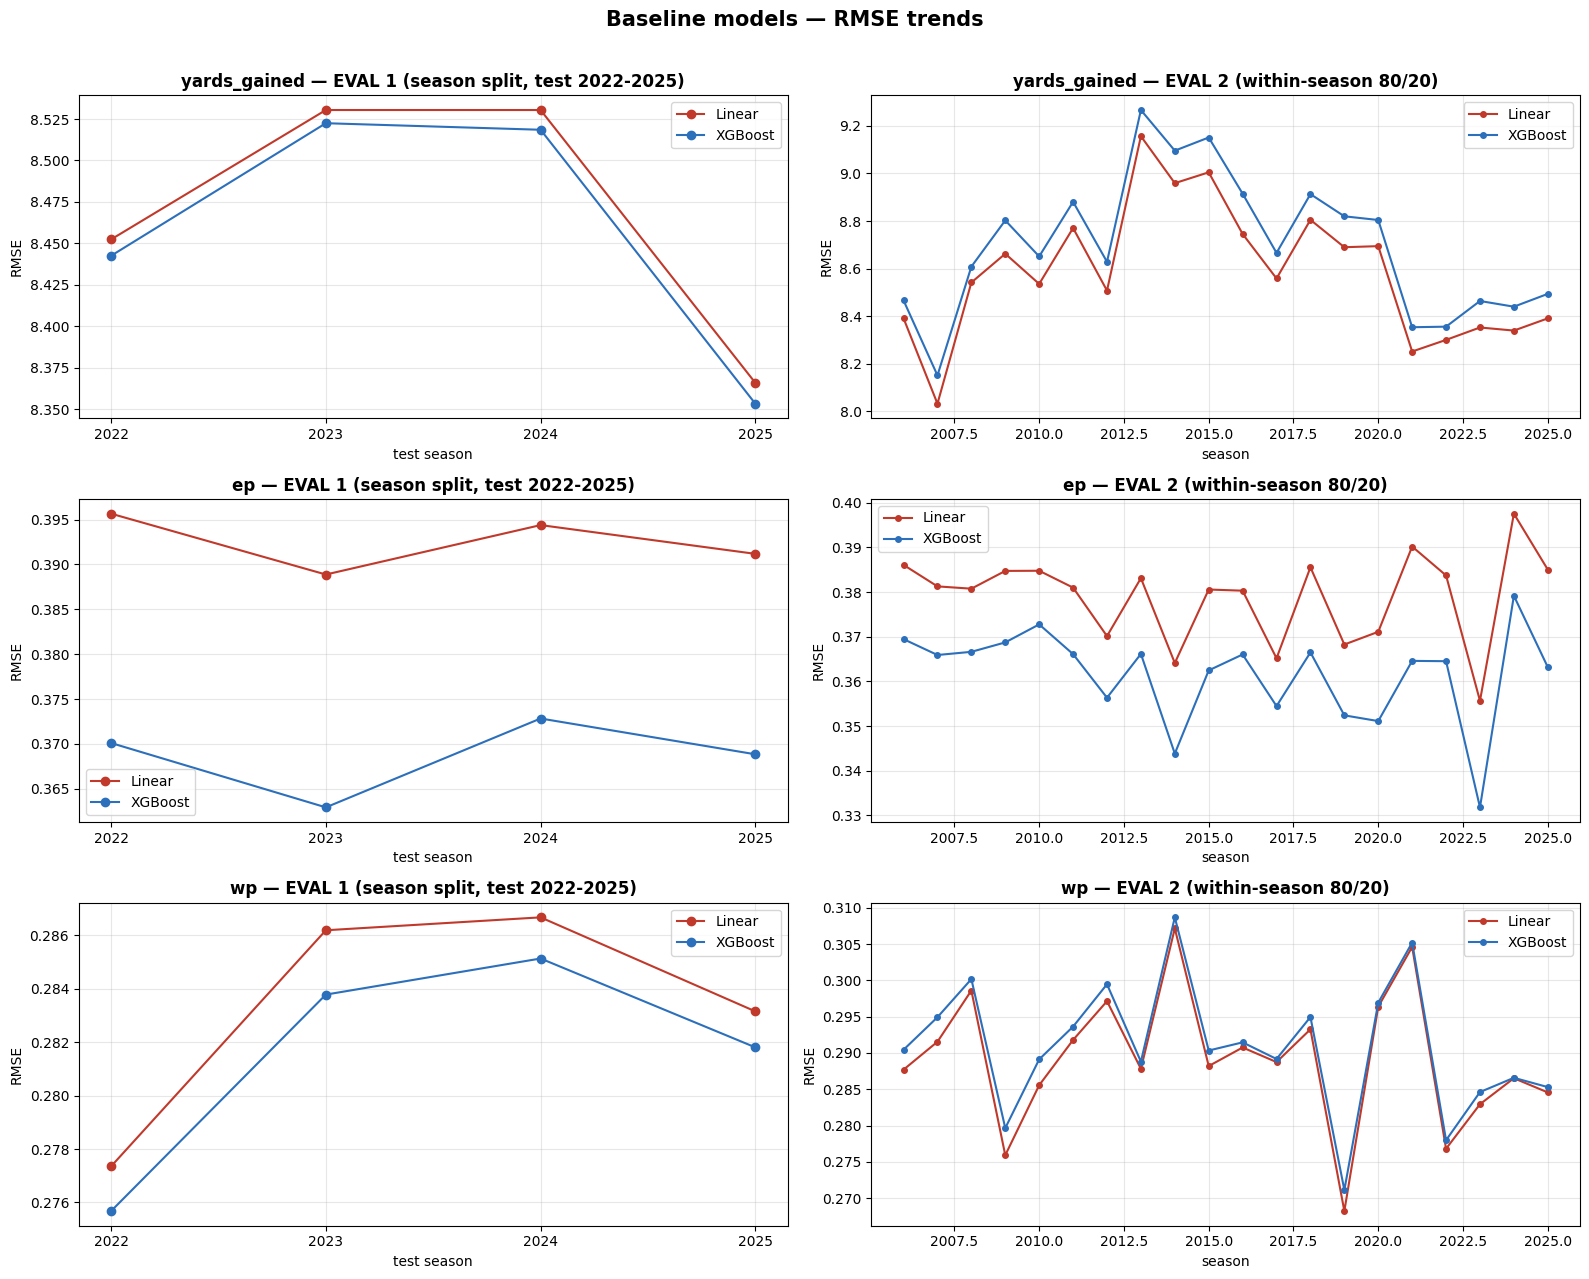


=== EVAL 1 summary (mean over test seasons) ===
                        RMSE     MAE
target       model                  
ep           Linear   0.3925  0.2942
             XGBoost  0.3687  0.2740
wp           Linear   0.2833  0.2347
             XGBoost  0.2816  0.2327
yards_gained Linear   8.4698  5.6656
             XGBoost  8.4592  5.6629

=== EVAL 2 summary (mean over seasons) ===
                        RMSE     MAE
target       model                  
ep           Linear   0.3789  0.2851
             XGBoost  0.3616  0.2695
wp           Linear   0.2892  0.2413
             XGBoost  0.2909  0.2417
yards_gained Linear   8.5843  5.7562
             XGBoost  8.6962  5.8363


In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

TARGETS = ['yards_gained', 'ep', 'wp']
NUM_FEATURES = ['ydstogo', 'yardline_100', 'goal_to_go']

data = work.dropna(subset=TARGETS + ['down', 'ydstogo', 'yardline_100', 'goal_to_go']).copy()
data['season'] = data['game_id'].str[:4].astype(int)

def build_features(dfin):
    X = dfin[NUM_FEATURES].copy()
    for d in [1, 2, 3, 4]:
        X[f'down_{d}'] = (dfin['down'].astype(int) == d).astype(int)
    return X

def make_models():
    return {
        'Linear': LinearRegression(),
        'XGBoost': XGBRegressor(n_estimators=300, max_depth=6,
                                learning_rate=0.1, subsample=0.8,
                                colsample_bytree=0.8, n_jobs=-1,
                                random_state=42, verbosity=0),
    }

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

# ============================================================
# EVAL 1: season split (train 2006-2021, test 2022-2025)
# per test-season metrics
# ====================================ㅁ========================
train_seasons = list(range(2006, 2022))
test_seasons = [2022, 2023, 2024, 2025]

train = data[data['season'].isin(train_seasons)]
test_all = data[data['season'].isin(test_seasons)]

X_train = build_features(train)
results1 = []

for target in TARGETS:
    y_train = train[target].values
    models = make_models()
    for mname, model in models.items():
        model.fit(X_train, y_train)
        for ts in test_seasons:
            sub = test_all[test_all['season'] == ts]
            if len(sub) == 0:
                continue
            X_te = build_features(sub)
            y_te = sub[target].values
            rmse, mae = evaluate(y_te, model.predict(X_te))
            results1.append({'target': target, 'model': mname,
                             'test_season': ts, 'n': len(sub),
                             'RMSE': rmse, 'MAE': mae})

res1 = pd.DataFrame(results1)
print("=" * 70)
print("EVAL 1: SEASON SPLIT (train 2006-2021, test per season 2022-2025)")
print("=" * 70)
for target in TARGETS:
    print(f"\n--- target: {target} ---")
    piv = res1[res1['target'] == target].pivot_table(
        index='test_season', columns='model', values=['RMSE', 'MAE'])
    print(piv.round(4).to_string())

# ============================================================
# EVAL 2: within-season 80/20 (game_id level split), per season
# ============================================================
results2 = []
all_seasons = sorted(data['season'].unique())
rng = np.random.RandomState(42)

for season in all_seasons:
    sdata = data[data['season'] == season]
    games = sdata['game_id'].unique()
    rng.shuffle(games)
    n_train = int(0.8 * len(games))
    train_games = set(games[:n_train])
    tr = sdata[sdata['game_id'].isin(train_games)]
    te = sdata[~sdata['game_id'].isin(train_games)]
    if len(te) == 0 or len(tr) == 0:
        continue
    X_tr = build_features(tr)
    X_te = build_features(te)
    for target in TARGETS:
        y_tr = tr[target].values
        y_te = te[target].values
        models = make_models()
        for mname, model in models.items():
            model.fit(X_tr, y_tr)
            rmse, mae = evaluate(y_te, model.predict(X_te))
            results2.append({'season': season, 'target': target,
                             'model': mname, 'n_test': len(te),
                             'RMSE': rmse, 'MAE': mae})

res2 = pd.DataFrame(results2)
print("\n" + "=" * 70)
print("EVAL 2: WITHIN-SEASON 80/20 (game-level split), per season")
print("=" * 70)
for target in TARGETS:
    print(f"\n--- target: {target} ---")
    piv = res2[res2['target'] == target].pivot_table(
        index='season', columns='model', values=['RMSE', 'MAE'])
    print(piv.round(4).to_string())

# ============================================================
# PLOTS
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle('Baseline models — RMSE trends', fontsize=15, fontweight='bold')
colors = {'Linear': '#C0392B', 'XGBoost': '#2C6FBB'}

for r, target in enumerate(TARGETS):
    ax = axes[r, 0]
    sub = res1[res1['target'] == target]
    for mname in ['Linear', 'XGBoost']:
        m = sub[sub['model'] == mname].sort_values('test_season')
        ax.plot(m['test_season'], m['RMSE'], 'o-', color=colors[mname], label=mname)
    ax.set_title(f'{target} — EVAL 1 (season split, test 2022-2025)', fontweight='bold')
    ax.set_xlabel('test season'); ax.set_ylabel('RMSE'); ax.legend(); ax.grid(alpha=0.3)
    ax.set_xticks(test_seasons)

    ax = axes[r, 1]
    sub = res2[res2['target'] == target]
    for mname in ['Linear', 'XGBoost']:
        m = sub[sub['model'] == mname].sort_values('season')
        ax.plot(m['season'], m['RMSE'], 'o-', color=colors[mname], label=mname, markersize=4)
    ax.set_title(f'{target} — EVAL 2 (within-season 80/20)', fontweight='bold')
    ax.set_xlabel('season'); ax.set_ylabel('RMSE'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('baseline_rmse_trends.png', dpi=130, bbox_inches='tight')
plt.show()

print("\n=== EVAL 1 summary (mean over test seasons) ===")
print(res1.groupby(['target', 'model'])[['RMSE', 'MAE']].mean().round(4).to_string())
print("\n=== EVAL 2 summary (mean over seasons) ===")
print(res2.groupby(['target', 'model'])[['RMSE', 'MAE']].mean().round(4).to_string())

=== target 분포 (got_first_down) ===
got_first_down
0    477638
1    197928
Name: count, dtype: int64
first down 획득률: 29.3%

EVAL 1: SEASON SPLIT (train 2006-2021, test per season 2022-2025)

--- model: Logistic ---
             accuracy  precision  recall      F1  ROC_AUC
test_season                                              
2022           0.7335     0.6147  0.2735  0.3786   0.6885
2023           0.7389     0.6039  0.2766  0.3794   0.6908
2024           0.7302     0.6126  0.2728  0.3775   0.6891
2025           0.7358     0.6142  0.2862  0.3905   0.6875

--- model: XGBoost ---
             accuracy  precision  recall      F1  ROC_AUC
test_season                                              
2022           0.7350     0.6301  0.2593  0.3674   0.6909
2023           0.7393     0.6135  0.2605  0.3657   0.6929
2024           0.7308     0.6233  0.2583  0.3653   0.6894
2025           0.7367     0.6278  0.2691  0.3767   0.6903

EVAL 2: WITHIN-SEASON 80/20 (game-level split), per season

--- m

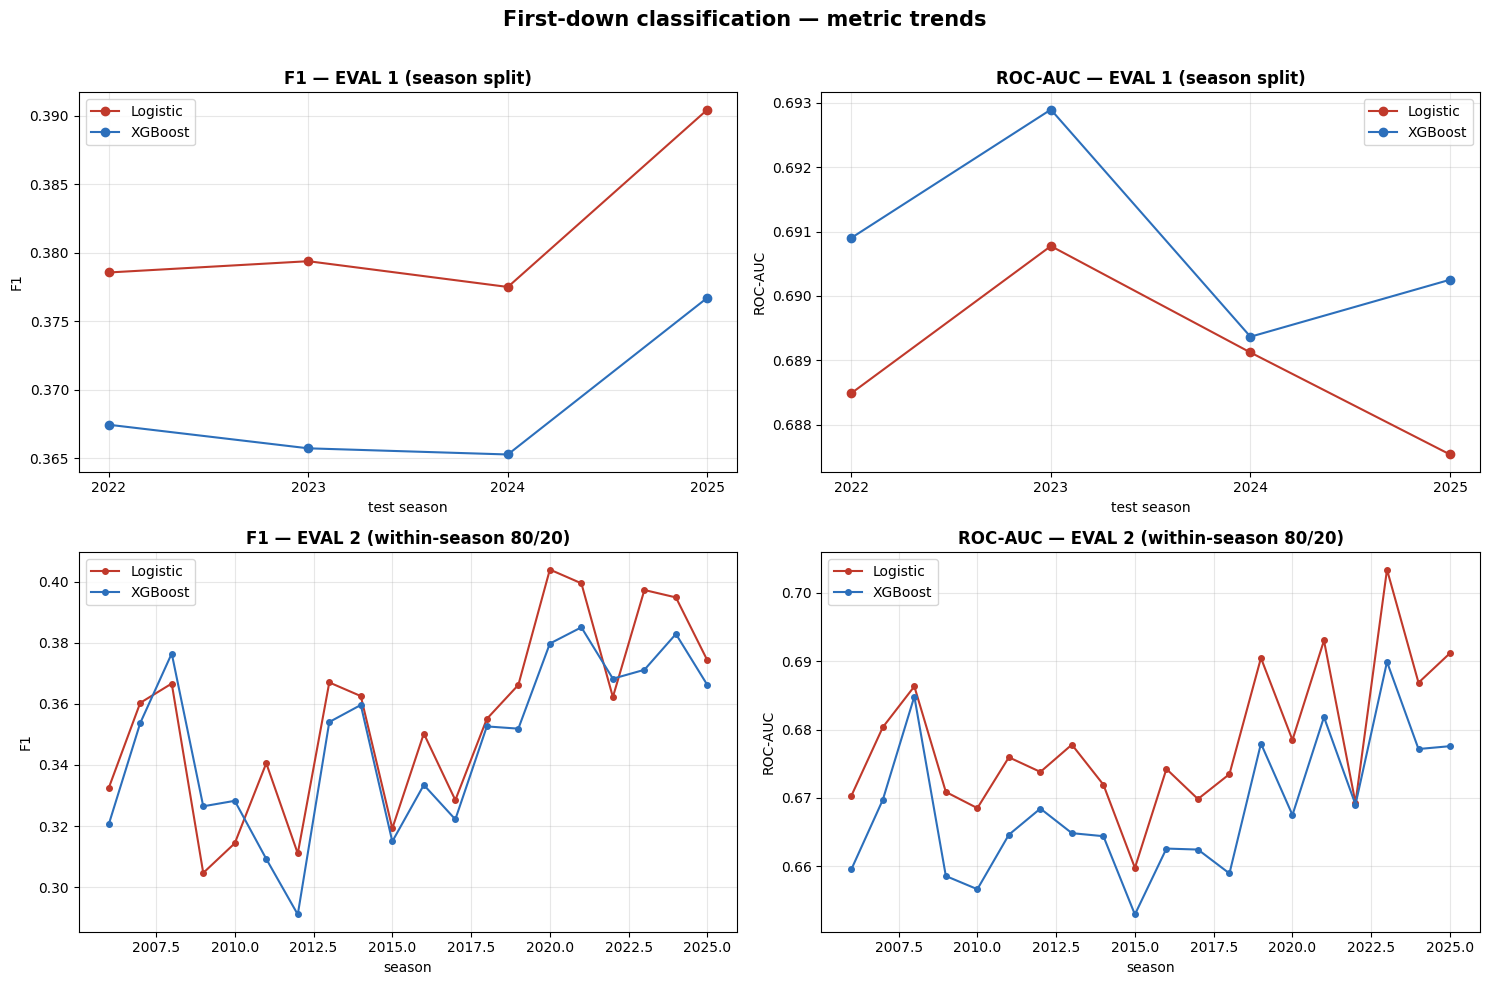


=== confusion matrix (EVAL1, test 2022-2025 pooled) ===

Logistic:
          pred_0  pred_1
actual_0   91243    7272
actual_1   29822   11438

XGBoost:
          pred_0  pred_1
actual_0   91998    6517
actual_1   30459   10801

=== EVAL 1 summary (mean over test seasons) ===
          accuracy  precision  recall      F1  ROC_AUC
model                                                 
Logistic    0.7346     0.6113  0.2773  0.3815   0.6890
XGBoost     0.7354     0.6237  0.2618  0.3688   0.6909

=== EVAL 2 summary (mean over seasons) ===
          accuracy  precision  recall      F1  ROC_AUC
model                                                 
Logistic    0.7314     0.5978  0.2540  0.3555   0.6783
XGBoost     0.7277     0.5824  0.2481  0.3474   0.6685


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from xgboost import XGBClassifier

NUM_FEATURES = ['ydstogo', 'yardline_100', 'goal_to_go']

data = work.copy()
data['got_first_down'] = (
    (data['first_down_rush'] == 1) |
    (data['first_down_pass'] == 1) |
    (data['first_down_penalty'] == 1)
).astype(int)

data = data.dropna(subset=['down', 'ydstogo', 'yardline_100', 'goal_to_go',
                           'got_first_down'])
data['season'] = data['game_id'].str[:4].astype(int)

print("=== target 분포 (got_first_down) ===")
print(data['got_first_down'].value_counts())
print(f"first down 획득률: {100*data['got_first_down'].mean():.1f}%")

def build_features(dfin):
    X = dfin[NUM_FEATURES].copy()
    for d in [1, 2, 3, 4]:
        X[f'down_{d}'] = (dfin['down'].astype(int) == d).astype(int)
    return X

def make_models():
    return {
        'Logistic': LogisticRegression(max_iter=1000),
        'XGBoost': XGBClassifier(n_estimators=300, max_depth=6,
                                 learning_rate=0.1, subsample=0.8,
                                 colsample_bytree=0.8, n_jobs=-1,
                                 random_state=42, eval_metric='logloss',
                                 verbosity=0),
    }

def evaluate(y_true, y_pred, y_prob):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC':   roc_auc_score(y_true, y_prob),
    }

# ============================================================
# EVAL 1: season split (train 2006-2021, test per season 2022-2025)
# ============================================================
train_seasons = list(range(2006, 2022))
test_seasons = [2022, 2023, 2024, 2025]

train = data[data['season'].isin(train_seasons)]
test_all = data[data['season'].isin(test_seasons)]

X_train = build_features(train)
y_train = train['got_first_down'].values

results1 = []
fitted = {}
for mname, model in make_models().items():
    model.fit(X_train, y_train)
    fitted[mname] = model
    for ts in test_seasons:
        sub = test_all[test_all['season'] == ts]
        if len(sub) == 0:
            continue
        X_te = build_features(sub)
        y_te = sub['got_first_down'].values
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]
        m = evaluate(y_te, y_pred, y_prob)
        m.update({'model': mname, 'test_season': ts, 'n': len(sub)})
        results1.append(m)

res1 = pd.DataFrame(results1)
print("\n" + "=" * 70)
print("EVAL 1: SEASON SPLIT (train 2006-2021, test per season 2022-2025)")
print("=" * 70)
for mname in ['Logistic', 'XGBoost']:
    print(f"\n--- model: {mname} ---")
    sub = res1[res1['model'] == mname].set_index('test_season')
    print(sub[['accuracy', 'precision', 'recall', 'F1', 'ROC_AUC']].round(4).to_string())

# ============================================================
# EVAL 2: within-season 80/20 (game-level split), per season
# ============================================================
results2 = []
all_seasons = sorted(data['season'].unique())
rng = np.random.RandomState(42)

for season in all_seasons:
    sdata = data[data['season'] == season]
    games = sdata['game_id'].unique()
    rng.shuffle(games)
    n_train = int(0.8 * len(games))
    train_games = set(games[:n_train])
    tr = sdata[sdata['game_id'].isin(train_games)]
    te = sdata[~sdata['game_id'].isin(train_games)]
    if len(tr) == 0 or len(te) == 0:
        continue
    X_tr = build_features(tr)
    y_tr = tr['got_first_down'].values
    X_te = build_features(te)
    y_te = te['got_first_down'].values
    for mname, model in make_models().items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]
        m = evaluate(y_te, y_pred, y_prob)
        m.update({'season': season, 'model': mname})
        results2.append(m)

res2 = pd.DataFrame(results2)
print("\n" + "=" * 70)
print("EVAL 2: WITHIN-SEASON 80/20 (game-level split), per season")
print("=" * 70)
for mname in ['Logistic', 'XGBoost']:
    print(f"\n--- model: {mname} ---")
    sub = res2[res2['model'] == mname].set_index('season')
    print(sub[['accuracy', 'precision', 'recall', 'F1', 'ROC_AUC']].round(4).to_string())

# ============================================================
# PLOTS
# ============================================================
colors = {'Logistic': '#C0392B', 'XGBoost': '#2C6FBB'}
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('First-down classification — metric trends', fontsize=15, fontweight='bold')

ax = axes[0, 0]
for mname in ['Logistic', 'XGBoost']:
    s = res1[res1['model'] == mname].sort_values('test_season')
    ax.plot(s['test_season'], s['F1'], 'o-', color=colors[mname], label=mname)
ax.set_title('F1 — EVAL 1 (season split)', fontweight='bold')
ax.set_xlabel('test season'); ax.set_ylabel('F1'); ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(test_seasons)

ax = axes[0, 1]
for mname in ['Logistic', 'XGBoost']:
    s = res1[res1['model'] == mname].sort_values('test_season')
    ax.plot(s['test_season'], s['ROC_AUC'], 'o-', color=colors[mname], label=mname)
ax.set_title('ROC-AUC — EVAL 1 (season split)', fontweight='bold')
ax.set_xlabel('test season'); ax.set_ylabel('ROC-AUC'); ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(test_seasons)

ax = axes[1, 0]
for mname in ['Logistic', 'XGBoost']:
    s = res2[res2['model'] == mname].sort_values('season')
    ax.plot(s['season'], s['F1'], 'o-', color=colors[mname], label=mname, markersize=4)
ax.set_title('F1 — EVAL 2 (within-season 80/20)', fontweight='bold')
ax.set_xlabel('season'); ax.set_ylabel('F1'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
for mname in ['Logistic', 'XGBoost']:
    s = res2[res2['model'] == mname].sort_values('season')
    ax.plot(s['season'], s['ROC_AUC'], 'o-', color=colors[mname], label=mname, markersize=4)
ax.set_title('ROC-AUC — EVAL 2 (within-season 80/20)', fontweight='bold')
ax.set_xlabel('season'); ax.set_ylabel('ROC-AUC'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('firstdown_classification.png', dpi=130, bbox_inches='tight')
plt.show()

print("\n=== confusion matrix (EVAL1, test 2022-2025 pooled) ===")
for mname, model in fitted.items():
    X_te = build_features(test_all)
    y_te = test_all['got_first_down'].values
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    print(f"\n{mname}:")
    print(pd.DataFrame(cm, index=['actual_0', 'actual_1'],
                       columns=['pred_0', 'pred_1']).to_string())

print("\n=== EVAL 1 summary (mean over test seasons) ===")
print(res1.groupby('model')[['accuracy','precision','recall','F1','ROC_AUC']].mean().round(4).to_string())
print("\n=== EVAL 2 summary (mean over seasons) ===")
print(res2.groupby('model')[['accuracy','precision','recall','F1','ROC_AUC']].mean().round(4).to_string())

In [77]:
df[['drive','fixed_drive','fixed_drive_result']].head(50)


,drive,fixed_drive,fixed_drive_result
0,NaN,1.0,Missed field goal
1,1.0,1.0,Missed field goal
2,1.0,1.0,Missed field goal
3,1.0,1.0,Missed field goal
4,1.0,1.0,Missed field goal
5,1.0,1.0,Missed field goal
6,1.0,1.0,Missed field goal
7,1.0,1.0,Missed field goal
8,1.0,1.0,Missed field goal
9,1.0,1.0,Missed field goal
